In [28]:
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [29]:
rsa_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis'
EXCLUDE_RSA_MODEL = 'dinov3_vitl16'

rsa_by_tuning_path = os.path.join(rsa_dir, 'rsa_results_by_tuning.pkl')
rsa_by_area_path = os.path.join(rsa_dir, 'rsa_results_by_area.pkl')
rsa_by_area_finer_path = os.path.join(rsa_dir, 'rsa_results_by_area_finer.pkl')

if os.path.isfile(rsa_by_tuning_path):
    rsa_by_tuning = pd.read_pickle(rsa_by_tuning_path)
    rsa_by_tuning = rsa_by_tuning[rsa_by_tuning['model_name'] != EXCLUDE_RSA_MODEL].copy()
    print(f'[by_tuning] shape={rsa_by_tuning.shape}')
    print(f'  columns={rsa_by_tuning.columns.tolist()}')

print('-' * 60)

if os.path.isfile(rsa_by_area_path):
    rsa_by_area = pd.read_pickle(rsa_by_area_path)
    rsa_by_area = rsa_by_area[rsa_by_area['model_name'] != EXCLUDE_RSA_MODEL].copy()
    print(f'[by_area] shape={rsa_by_area.shape}')
    print(f'  columns={rsa_by_area.columns.tolist()}')

print('-' * 60)

if os.path.isfile(rsa_by_area_finer_path):
    rsa_by_area_finer = pd.read_pickle(rsa_by_area_finer_path)
    rsa_by_area_finer = rsa_by_area_finer[rsa_by_area_finer['model_name'] != EXCLUDE_RSA_MODEL].copy()
    print(f'[by_area_finer] shape={rsa_by_area_finer.shape}')
    print(f'  columns={rsa_by_area_finer.columns.tolist()}')
else:
    rsa_by_area_finer = None
    print('[by_area_finer] file not found:', rsa_by_area_finer_path)

print('-' * 60)

rsa_all_subsample_path = os.path.join(rsa_dir, 'rsa_results_all_subsample20pct.pkl')
rsa_by_session_path = os.path.join(rsa_dir, 'rsa_results_by_session.pkl')

if os.path.isfile(rsa_all_subsample_path):
    rsa_all_subsample = pd.read_pickle(rsa_all_subsample_path)
    rsa_all_subsample = rsa_all_subsample[rsa_all_subsample['model_name'] != EXCLUDE_RSA_MODEL].copy()
    print(f'[all_subsample_20pct] shape={rsa_all_subsample.shape}')
    print(f'  columns={rsa_all_subsample.columns.tolist()}')
else:
    rsa_all_subsample = None
    print('[all_subsample_20pct] file not found:', rsa_all_subsample_path)

print('-' * 60)

if os.path.isfile(rsa_by_session_path):
    rsa_by_session = pd.read_pickle(rsa_by_session_path)
    rsa_by_session = rsa_by_session[rsa_by_session['model_name'] != EXCLUDE_RSA_MODEL].copy()
    print(f'[by_session] shape={rsa_by_session.shape}')
    print(f'  columns={rsa_by_session.columns.tolist()}')
else:
    rsa_by_session = None
    print('[by_session] file not found:', rsa_by_session_path)


[by_tuning] shape=(30000, 7)
  columns=['model_name', 'tuning_type', 'repeat', 'spearman_r', 'spearman_p', 'pearson_r', 'pearson_p']
------------------------------------------------------------
[by_area] shape=(20000, 7)
  columns=['model_name', 'area', 'repeat', 'spearman_r', 'spearman_p', 'pearson_r', 'pearson_p']
------------------------------------------------------------
[by_area_finer] shape=(100000, 7)
  columns=['model_name', 'area', 'repeat', 'spearman_r', 'spearman_p', 'pearson_r', 'pearson_p']
------------------------------------------------------------
[all_subsample_20pct] shape=(2000, 7)
  columns=['model_name', 'repeat', 'n_units_sampled', 'spearman_r', 'spearman_p', 'pearson_r', 'pearson_p']
------------------------------------------------------------
[by_session] shape=(490, 8)
  columns=['model_name', 'session_id', 'n_units', 'repeat', 'spearman_r', 'spearman_p', 'pearson_r', 'pearson_p']


In [30]:
from contextlib import ExitStack
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

sns.set(style='white', context='talk')

tuning_order = ['single_tuning', 'multi_tuning', 'broad_tuning']
area_order = ['middle', 'anterior']
area_finer_order = ['MF', 'MB', 'MO', 'LPP', 'CLC', 'AF', 'AB', 'AO', 'PITP', 'AMC']

mset_t = set(rsa_by_tuning['model_name'])
mset_a = set(rsa_by_area['model_name'])
if rsa_by_area_finer is not None:
    mset_af = set(rsa_by_area_finer['model_name'])
    models = sorted(mset_t.intersection(mset_a).intersection(mset_af))
else:
    models = sorted(mset_t.intersection(mset_a))
print(f'共 {len(models)} 个模型将单独比较')

out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
os.makedirs(out_dir, exist_ok=True)

tuning_pdf_path = os.path.join(out_dir, 'pearson_r_by_tuning_type_all_models.pdf')
area_pdf_path = os.path.join(out_dir, 'pearson_r_by_area_all_models.pdf')
area_finer_pdf_path = os.path.join(out_dir, 'pearson_r_by_area_finer_all_models.pdf')
stats_out_path = os.path.join(out_dir, 'pearson_r_paired_stats_by_model.csv')

rng_ci = np.random.default_rng(42)

def bootstrap_ci_mean_diff(diff_vals, n_boot=2000, alpha=0.05):
    idx = rng_ci.integers(0, len(diff_vals), size=(n_boot, len(diff_vals)))
    boot_means = diff_vals[idx].mean(axis=1)
    lo = np.quantile(boot_means, alpha / 2)
    hi = np.quantile(boot_means, 1 - alpha / 2)
    return float(lo), float(hi)

def holm_correction(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = np.array(pvals)[order]
    adj_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p in enumerate(sorted_p):
        adj = (m - i) * p
        running_max = max(running_max, adj)
        adj_sorted[i] = min(running_max, 1.0)
    adj = np.empty(m, dtype=float)
    adj[order] = adj_sorted
    return adj

stats_rows = []

with ExitStack() as stack:
    tuning_pdf = stack.enter_context(PdfPages(tuning_pdf_path))
    area_pdf = stack.enter_context(PdfPages(area_pdf_path))
    if rsa_by_area_finer is not None:
        area_finer_pdf = stack.enter_context(PdfPages(area_finer_pdf_path))
    else:
        area_finer_pdf = None

    for model_name in models:
        tuning_m = rsa_by_tuning.loc[
            rsa_by_tuning['model_name'] == model_name,
            ['repeat', 'tuning_type', 'pearson_r']
        ].dropna().copy()
        area_m = rsa_by_area.loc[
            rsa_by_area['model_name'] == model_name,
            ['repeat', 'area', 'pearson_r']
        ].dropna().copy()
        area_fm = None
        if area_finer_pdf is not None:
            area_fm = rsa_by_area_finer.loc[
                rsa_by_area_finer['model_name'] == model_name,
                ['repeat', 'area', 'pearson_r']
            ].dropna().copy()

        fig1, ax1 = plt.subplots(figsize=(8, 5))
        sns.barplot(
            data=tuning_m,
            x='tuning_type',
            y='pearson_r',
            order=[t for t in tuning_order if t in tuning_m['tuning_type'].unique()],
            estimator=np.mean,
            errorbar=None,
            palette='Set2',
            ax=ax1
        )
        ax1.grid(False)
        ax1.set_title(f'{model_name} | Pearson r by tuning type')
        ax1.set_xlabel('tuning_type')
        ax1.set_ylabel('pearson_r')
        ax1.set_ylim(0, 0.35)

        tuning_wide = tuning_m.pivot_table(index='repeat', columns='tuning_type', values='pearson_r', aggfunc='mean')
        valid_cols = [t for t in tuning_order if t in tuning_wide.columns]
        if len(valid_cols) >= 3:
            friedman_stat, friedman_p = stats.friedmanchisquare(*[tuning_wide[c].dropna().values for c in valid_cols])
            ax1.text(0.02, 0.98, f'Friedman p={friedman_p:.2e}', transform=ax1.transAxes, ha='left', va='top', fontsize=10)

            pairs = []
            p_raws = []
            for i in range(len(valid_cols)):
                for j in range(i + 1, len(valid_cols)):
                    c1, c2 = valid_cols[i], valid_cols[j]
                    pair_df = tuning_wide[[c1, c2]].dropna()
                    if len(pair_df) == 0:
                        continue
                    w_stat, p_raw = stats.wilcoxon(pair_df[c1].values, pair_df[c2].values, alternative='two-sided')
                    pairs.append((c1, c2, len(pair_df), w_stat, p_raw))
                    p_raws.append(p_raw)
            if len(p_raws) > 0:
                p_holm = holm_correction(p_raws)
                for (c1, c2, n_pair, w_stat, p_raw), p_adj in zip(pairs, p_holm):
                    stats_rows.append({
                        'model_name': model_name,
                        'analysis': 'tuning_pairwise_wilcoxon',
                        'contrast': f'{c1} vs {c2}',
                        'n_pairs': n_pair,
                        'stat': w_stat,
                        'p_raw': p_raw,
                        'p_adj_holm': p_adj,
                        'delta_mean': np.nan,
                        'ci_low': np.nan,
                        'ci_high': np.nan,
                    })
            stats_rows.append({
                'model_name': model_name,
                'analysis': 'tuning_friedman',
                'contrast': 'all',
                'n_pairs': len(tuning_wide.dropna()),
                'stat': friedman_stat,
                'p_raw': friedman_p,
                'p_adj_holm': np.nan,
                'delta_mean': np.nan,
                'ci_low': np.nan,
                'ci_high': np.nan,
            })

        fig1.tight_layout()
        tuning_pdf.savefig(fig1, bbox_inches='tight')
        plt.close(fig1)

        fig2, ax2 = plt.subplots(figsize=(5, 5))
        area_order_valid = [a for a in area_order if a in area_m['area'].unique()]
        sns.barplot(
            data=area_m,
            x='area',
            y='pearson_r',
            order=area_order_valid,
            estimator=np.mean,
            errorbar=None,
            palette='Set1',
            ax=ax2
        )
        ax2.grid(False)
        ax2.set_title(f'{model_name} | Pearson r by area')
        ax2.set_xlabel('area')
        ax2.set_ylabel('pearson_r')
        ax2.set_ylim(0, 0.35)

        area_wide = area_m.pivot_table(index='repeat', columns='area', values='pearson_r', aggfunc='mean')
        if set(area_order).issubset(set(area_wide.columns)):
            pair_df = area_wide[area_order].dropna()
            middle_vals = pair_df['middle'].values
            anterior_vals = pair_df['anterior'].values
            diffs = middle_vals - anterior_vals

            t_stat, p_t = stats.ttest_rel(middle_vals, anterior_vals)
            w_stat, p_w = stats.wilcoxon(middle_vals, anterior_vals, alternative='two-sided')
            d_mean = float(np.mean(diffs))
            ci_low, ci_high = bootstrap_ci_mean_diff(diffs)

            y_max = max([p.get_height() for p in ax2.patches])
            y_min = min([p.get_height() for p in ax2.patches])
            h = max((y_max - y_min) * 0.08, 0.002)
            y = y_max + h
            x1, x2 = area_order_valid.index('middle'), area_order_valid.index('anterior')
            ax2.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='k')
            p_text = f'p={p_t:.2e}' if p_t >= 1e-300 else 'p<1e-300'
            ax2.text((x1 + x2) * 0.5, y + h, f'{p_text}; Δ={d_mean:.4f}', ha='center', va='bottom', fontsize=9)

            stats_rows.append({
                'model_name': model_name,
                'analysis': 'area_paired_ttest',
                'contrast': 'middle - anterior',
                'n_pairs': len(pair_df),
                'stat': t_stat,
                'p_raw': p_t,
                'p_adj_holm': np.nan,
                'delta_mean': d_mean,
                'ci_low': ci_low,
                'ci_high': ci_high,
            })
            stats_rows.append({
                'model_name': model_name,
                'analysis': 'area_wilcoxon',
                'contrast': 'middle - anterior',
                'n_pairs': len(pair_df),
                'stat': w_stat,
                'p_raw': p_w,
                'p_adj_holm': np.nan,
                'delta_mean': d_mean,
                'ci_low': ci_low,
                'ci_high': ci_high,
            })

        fig2.tight_layout()
        area_pdf.savefig(fig2, bbox_inches='tight')
        plt.close(fig2)

        if area_finer_pdf is not None and area_fm is not None and len(area_fm) > 0:
            fig3, ax3 = plt.subplots(figsize=(14, 5))
            area_finer_order_valid = [a for a in area_finer_order if a in area_fm['area'].unique()]
            sns.barplot(
                data=area_fm,
                x='area',
                y='pearson_r',
                order=area_finer_order_valid,
                estimator=np.mean,
                errorbar=None,
                palette='Set2',
                ax=ax3
            )
            ax3.grid(False)
            ax3.set_title(f'{model_name} | Pearson r by area (finer, n=200/repeat)')
            ax3.set_xlabel('area')
            ax3.set_ylabel('pearson_r')
            ax3.set_ylim(0, 0.35)
            ax3.tick_params(axis='x', rotation=45)

            area_f_wide = area_fm.pivot_table(index='repeat', columns='area', values='pearson_r', aggfunc='mean')
            valid_af = [a for a in area_finer_order if a in area_f_wide.columns]
            if len(valid_af) >= 3:
                full_rows = area_f_wide[valid_af].dropna()
                if len(full_rows) >= 3:
                    friedman_stat, friedman_p = stats.friedmanchisquare(*[full_rows[c].values for c in valid_af])
                    ax3.text(0.02, 0.98, f'Friedman p={friedman_p:.2e}', transform=ax3.transAxes, ha='left', va='top', fontsize=10)
                    stats_rows.append({
                        'model_name': model_name,
                        'analysis': 'area_finer_friedman',
                        'contrast': 'all',
                        'n_pairs': len(full_rows),
                        'stat': friedman_stat,
                        'p_raw': friedman_p,
                        'p_adj_holm': np.nan,
                        'delta_mean': np.nan,
                        'ci_low': np.nan,
                        'ci_high': np.nan,
                    })

            fig3.tight_layout()
            area_finer_pdf.savefig(fig3, bbox_inches='tight')
            plt.close(fig3)

if len(stats_rows) > 0:
    pd.DataFrame(stats_rows).to_csv(stats_out_path, index=False)

print(f'已保存: {tuning_pdf_path}')
print(f'已保存: {area_pdf_path}')
if rsa_by_area_finer is not None:
    print(f'已保存: {area_finer_pdf_path}')
print(f'已保存: {stats_out_path}')



共 10 个模型将单独比较


已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_tuning_type_all_models.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_area_all_models.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_area_finer_all_models.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_paired_stats_by_model.csv


            model_name    area  repeat  ratio_to_alexnet
0  CLIP ViT-L-14 Image  middle       0          0.608490
1   CLIP ViT-L-14 Text  middle       0          0.606413
2      CLIP RN50 Image  middle       0          0.763580
3       CLIP RN50 Text  middle       0          0.496912
4     CLIP RN101 Image  middle       0          0.696443
ratio data shape: (18000, 6)
paired t-test (middle vs anterior, n_models=9): t=-9.1049, p=1.7016e-05
mean difference (middle - anterior) = -0.0299


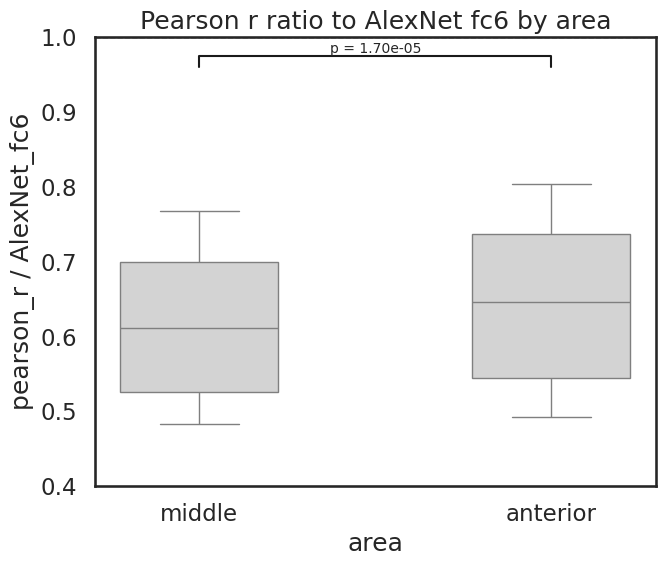

已保存图: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_area_boxplot.pdf
已保存绘图数据: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_area_plot_data.csv
pearson_r paired t-test (middle vs anterior, n_models=10): t=7.3895, p=4.1493e-05
mean difference (middle - anterior) = 0.0188


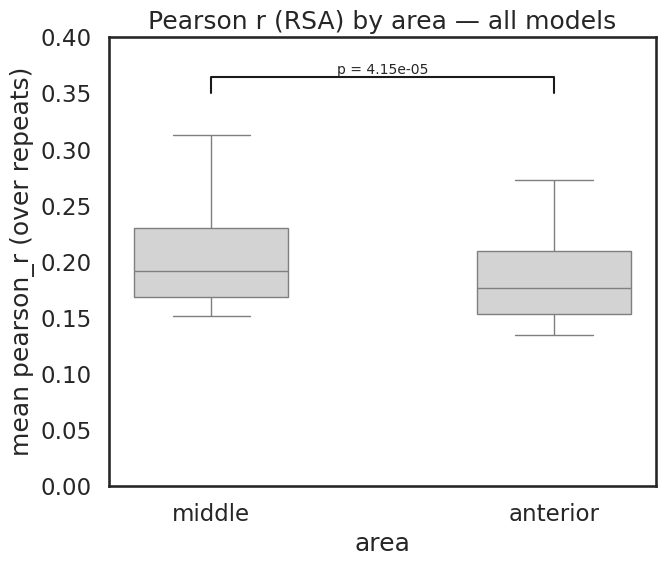

已保存图: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_area_middle_anterior_all_models_boxplot.pdf
已保存绘图数据: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_area_middle_anterior_all_models_plot_data.csv


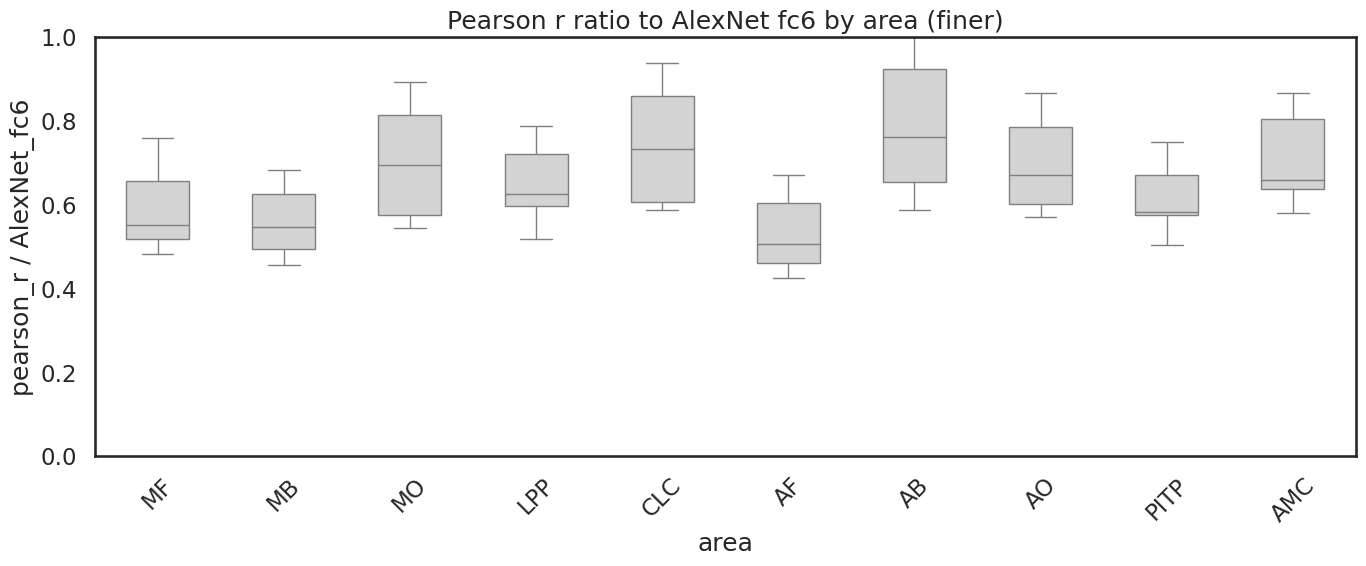

已保存图: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_area_finer_boxplot.pdf
已保存绘图数据: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_area_finer_plot_data.csv


In [31]:
alexnet_name = 'AlexNet fc6'

area_ratio_df = rsa_by_area[['model_name', 'area', 'repeat', 'pearson_r']].dropna().copy()

alex_ref = area_ratio_df.loc[
    area_ratio_df['model_name'] == alexnet_name,
    ['area', 'repeat', 'pearson_r']
].rename(columns={'pearson_r': 'pearson_r_alexnet'})

other_models = sorted([m for m in area_ratio_df['model_name'].unique() if m != alexnet_name])

area_ratio_df = area_ratio_df.loc[area_ratio_df['model_name'].isin(other_models)].merge(
    alex_ref,
    on=['area', 'repeat'],
    how='inner'
)

area_ratio_df = area_ratio_df[area_ratio_df['pearson_r_alexnet'] != 0].copy()
area_ratio_df['ratio_to_alexnet'] = area_ratio_df['pearson_r'] / area_ratio_df['pearson_r_alexnet']

print(area_ratio_df[['model_name', 'area', 'repeat', 'ratio_to_alexnet']].head())
print('ratio data shape:', area_ratio_df.shape)

plot_df = area_ratio_df.groupby(['model_name', 'area'], as_index=False)['ratio_to_alexnet'].mean()

paired_df = plot_df.pivot(index='model_name', columns='area', values='ratio_to_alexnet').dropna()
if {'middle', 'anterior'}.issubset(set(paired_df.columns)):
    t_stat, p_val = stats.ttest_rel(paired_df['middle'].values, paired_df['anterior'].values)
    mean_diff = (paired_df['middle'] - paired_df['anterior']).mean()
    print(f'paired t-test (middle vs anterior, n_models={len(paired_df)}): t={t_stat:.4f}, p={p_val:.4e}')
    print(f'mean difference (middle - anterior) = {mean_diff:.4f}')
else:
    print('无法进行配对t检验：middle/anterior 缺失')

out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
os.makedirs(out_dir, exist_ok=True)
pdf_out = os.path.join(out_dir, 'ratio_to_alexnet_by_area_boxplot.pdf')
csv_out = os.path.join(out_dir, 'ratio_to_alexnet_by_area_plot_data.csv')

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(
    data=plot_df,
    x='area',
    y='ratio_to_alexnet',
    order=['middle', 'anterior'],
    showfliers=False,
    width=0.45,
    color='lightgray',
    ax=ax
)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Pearson r ratio to AlexNet fc6 by area')
ax.set_xlabel('area')
ax.set_ylabel('pearson_r / AlexNet_fc6')
ax.set_ylim(0.4, 1)

if {'middle', 'anterior'}.issubset(set(paired_df.columns)):
    y = 0.96
    h = 0.015
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], lw=1.5, c='k')
    p_text = f'p = {p_val:.2e}' if p_val >= 1e-300 else 'p < 1e-300'
    ax.text(0.5, y + h, p_text, ha='center', va='bottom', fontsize=10)

leg = ax.get_legend()
if leg is not None:
    leg.remove()
fig.tight_layout()
fig.savefig(pdf_out, dpi=300, bbox_inches='tight')
plt.show()

plot_df.to_csv(csv_out, index=False)
print(f'已保存图: {pdf_out}')
print(f'已保存绘图数据: {csv_out}')

area_corr_all = rsa_by_area[['model_name', 'area', 'repeat', 'pearson_r']].dropna().copy()
area_corr_all = area_corr_all.loc[area_corr_all['area'].isin(['middle', 'anterior'])].copy()
plot_df_corr = area_corr_all.groupby(['model_name', 'area'], as_index=False)['pearson_r'].mean()

paired_df_c = plot_df_corr.pivot(index='model_name', columns='area', values='pearson_r').dropna()
if {'middle', 'anterior'}.issubset(set(paired_df_c.columns)):
    t_stat_c, p_val_c = stats.ttest_rel(paired_df_c['middle'].values, paired_df_c['anterior'].values)
    mean_diff_c = (paired_df_c['middle'] - paired_df_c['anterior']).mean()
    print(f'pearson_r paired t-test (middle vs anterior, n_models={len(paired_df_c)}): t={t_stat_c:.4f}, p={p_val_c:.4e}')
    print(f'mean difference (middle - anterior) = {mean_diff_c:.4f}')
else:
    p_val_c = np.nan
    print('无法进行 pearson_r 配对t检验：middle/anterior 缺失')

pdf_corr = os.path.join(out_dir, 'pearson_r_by_area_middle_anterior_all_models_boxplot.pdf')
csv_corr = os.path.join(out_dir, 'pearson_r_by_area_middle_anterior_all_models_plot_data.csv')

fig_c, ax_c = plt.subplots(figsize=(7, 6))
sns.boxplot(
    data=plot_df_corr,
    x='area',
    y='pearson_r',
    order=['middle', 'anterior'],
    showfliers=False,
    width=0.45,
    color='lightgray',
    ax=ax_c
)
ax_c.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax_c.set_title('Pearson r (RSA) by area — all models')
ax_c.set_xlabel('area')
ax_c.set_ylabel('mean pearson_r (over repeats)')
ax_c.set_ylim(0, 0.4)

if {'middle', 'anterior'}.issubset(set(paired_df_c.columns)):
    y_c = 0.35
    h_c = 0.015
    ax_c.plot([0, 0, 1, 1], [y_c, y_c + h_c, y_c + h_c, y_c], lw=1.5, c='k')
    p_text_c = f'p = {p_val_c:.2e}' if p_val_c >= 1e-300 else 'p < 1e-300'
    ax_c.text(0.5, y_c + h_c, p_text_c, ha='center', va='bottom', fontsize=10)

leg_c = ax_c.get_legend()
if leg_c is not None:
    leg_c.remove()
fig_c.tight_layout()
fig_c.savefig(pdf_corr, dpi=300, bbox_inches='tight')
plt.show()

plot_df_corr.to_csv(csv_corr, index=False)
print(f'已保存图: {pdf_corr}')
print(f'已保存绘图数据: {csv_corr}')

if rsa_by_area_finer is not None:
    area_finer_order = ['MF', 'MB', 'MO', 'LPP', 'CLC', 'AF', 'AB', 'AO', 'PITP', 'AMC']
    area_ratio_f = rsa_by_area_finer[['model_name', 'area', 'repeat', 'pearson_r']].dropna().copy()
    alex_ref_f = area_ratio_f.loc[
        area_ratio_f['model_name'] == alexnet_name,
        ['area', 'repeat', 'pearson_r']
    ].rename(columns={'pearson_r': 'pearson_r_alexnet'})
    other_models_f = sorted([m for m in area_ratio_f['model_name'].unique() if m != alexnet_name])
    area_ratio_f = area_ratio_f.loc[area_ratio_f['model_name'].isin(other_models_f)].merge(
        alex_ref_f,
        on=['area', 'repeat'],
        how='inner'
    )
    area_ratio_f = area_ratio_f[area_ratio_f['pearson_r_alexnet'] != 0].copy()
    area_ratio_f['ratio_to_alexnet'] = area_ratio_f['pearson_r'] / area_ratio_f['pearson_r_alexnet']
    plot_df_f = area_ratio_f.groupby(['model_name', 'area'], as_index=False)['ratio_to_alexnet'].mean()
    pdf_out_f = os.path.join(out_dir, 'ratio_to_alexnet_by_area_finer_boxplot.pdf')
    csv_out_f = os.path.join(out_dir, 'ratio_to_alexnet_by_area_finer_plot_data.csv')
    order_f = [a for a in area_finer_order if a in plot_df_f['area'].unique()]
    fig_f, ax_f = plt.subplots(figsize=(14, 6))
    sns.boxplot(
        data=plot_df_f,
        x='area',
        y='ratio_to_alexnet',
        order=order_f,
        showfliers=False,
        width=0.5,
        color='lightgray',
        ax=ax_f
    )
    ax_f.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax_f.set_title('Pearson r ratio to AlexNet fc6 by area (finer)')
    ax_f.set_xlabel('area')
    ax_f.set_ylabel('pearson_r / AlexNet_fc6')
    ax_f.set_ylim(0, 1)
    ax_f.tick_params(axis='x', rotation=45)
    fig_f.tight_layout()
    fig_f.savefig(pdf_out_f, dpi=300, bbox_inches='tight')
    plt.show()
    plot_df_f.to_csv(csv_out_f, index=False)
    print(f'已保存图: {pdf_out_f}')
    print(f'已保存绘图数据: {csv_out_f}')


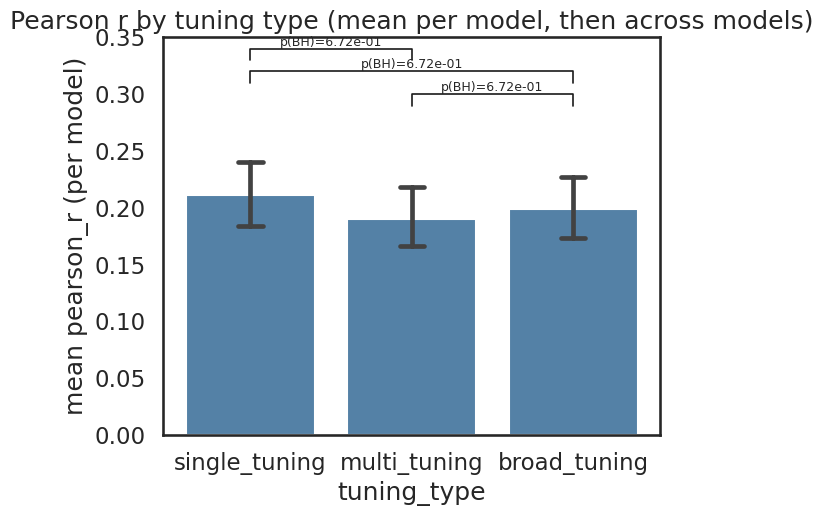

已保存图: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_tuning_type_across_models_mean_per_model.pdf
已保存绘图数据: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_tuning_type_across_models_mean_per_model.csv
每个tuning_type的模型数(=N for error bar):
tuning_type
single_tuning    10
multi_tuning     10
broad_tuning     10
Name: model_name, dtype: int64

跨模型统计:
                   mean       std  count
tuning_type                             
single_tuning  0.211498  0.049670     10
multi_tuning   0.190187  0.045238     10
broad_tuning   0.198939  0.045690     10

Pairwise Welch t-test + BH(FDR):
single_tuning vs multi_tuning: n=10, t=1.0031, p_raw=3.29e-01, p_bh=6.72e-01
single_tuning vs broad_tuning: n=10, t=0.5885, p_raw=5.64e-01, p_bh=6.72e-01
multi_tuning vs broad_tuning: n=10, t=-0.4305, p_raw=6.72e-01, p_bh=6.72e-01


In [32]:
tuning_order = ['single_tuning', 'multi_tuning', 'broad_tuning']

raw = rsa_by_tuning[['model_name', 'tuning_type', 'repeat', 'pearson_r']].dropna().copy()

model_means = (
    raw.groupby(['model_name', 'tuning_type'], as_index=False)['pearson_r']
       .mean()
       .rename(columns={'pearson_r': 'pearson_r_mean_per_model'})
)
model_means['tuning_type'] = pd.Categorical(model_means['tuning_type'], categories=tuning_order, ordered=True)

wide = model_means.pivot(index='model_name', columns='tuning_type', values='pearson_r_mean_per_model')

pairs = [('single_tuning', 'multi_tuning'), ('single_tuning', 'broad_tuning'), ('multi_tuning', 'broad_tuning')]
raw_p = []
pair_info = []
for a, b in pairs:
    if a not in wide.columns or b not in wide.columns:
        continue
    d = wide[[a, b]].dropna()
    if len(d) < 2:
        continue
    t_stat, p_val = stats.ttest_ind(d[a].values, d[b].values, equal_var=False)
    raw_p.append(p_val)
    pair_info.append({'a': a, 'b': b, 'n_models': len(d), 't': t_stat, 'p_raw': p_val})

if len(raw_p) > 0:
    pvals = np.array(raw_p)
    order = np.argsort(pvals)
    ranked = pvals[order]
    m = len(pvals)
    bh = ranked * m / (np.arange(1, m + 1))
    bh = np.minimum.accumulate(bh[::-1])[::-1]
    bh = np.clip(bh, 0, 1)
    p_bh = np.empty(m)
    p_bh[order] = bh
    for i, info in enumerate(pair_info):
        info['p_bh'] = float(p_bh[i])

out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
os.makedirs(out_dir, exist_ok=True)
fig_out = os.path.join(out_dir, 'pearson_r_by_tuning_type_across_models_mean_per_model.pdf')
data_out = os.path.join(out_dir, 'pearson_r_by_tuning_type_across_models_mean_per_model.csv')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.barplot(
    data=model_means,
    x='tuning_type',
    y='pearson_r_mean_per_model',
    order=tuning_order,
    estimator=np.mean,
    errorbar=('ci', 95),
    capsize=0.15,
    color='steelblue',
    ax=ax
)
ax.grid(False)
ax.set_title('Pearson r by tuning type (mean per model, then across models)')
ax.set_xlabel('tuning_type')
ax.set_ylabel('mean pearson_r (per model)')
ax.set_ylim(0, 0.35)

# 在图上标注 BH 矫正后的 p 值
if len(pair_info) > 0:
    y0 = 0.33
    h = 0.01
    x_map = {k: i for i, k in enumerate(tuning_order)}
    for j, info in enumerate(pair_info):
        x1 = x_map[info['a']]
        x2 = x_map[info['b']]
        y = y0 - j * 0.02
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='k')
        ax.text((x1 + x2) * 0.5, y + h, f"p(BH)={info['p_bh']:.2e}", ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig(fig_out, dpi=300, bbox_inches='tight')
plt.show()

model_means.to_csv(data_out, index=False)
print(f'已保存图: {fig_out}')
print(f'已保存绘图数据: {data_out}')

print('每个tuning_type的模型数(=N for error bar):')
print(model_means.groupby('tuning_type')['model_name'].nunique())
print('\n跨模型统计:')
print(model_means.groupby('tuning_type')['pearson_r_mean_per_model'].agg(['mean', 'std', 'count']))
print('\nPairwise Welch t-test + BH(FDR):')
for info in pair_info:
    print(f"{info['a']} vs {info['b']}: n={info['n_models']}, t={info['t']:.4f}, p_raw={info['p_raw']:.2e}, p_bh={info['p_bh']:.2e}")


已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_all_subsample20pct_by_model.pdf


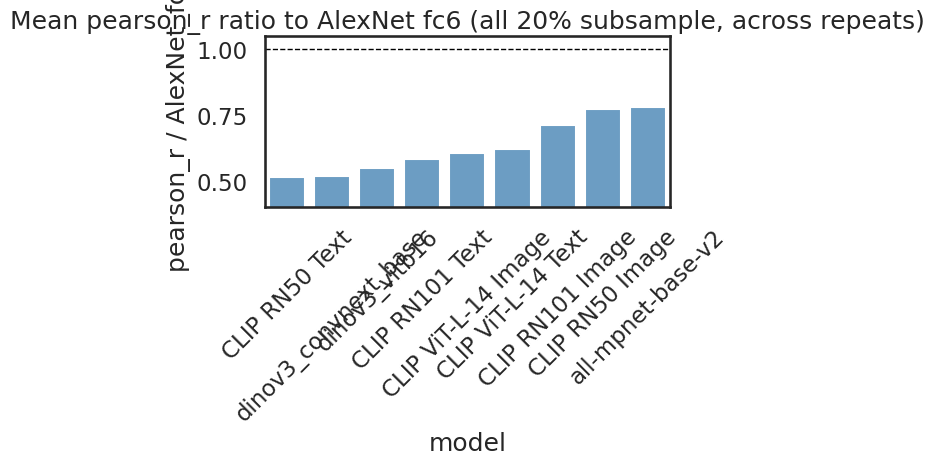

已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_all_subsample20pct_bar.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_all_subsample20pct.csv
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/pearson_r_by_session_per_model.pdf


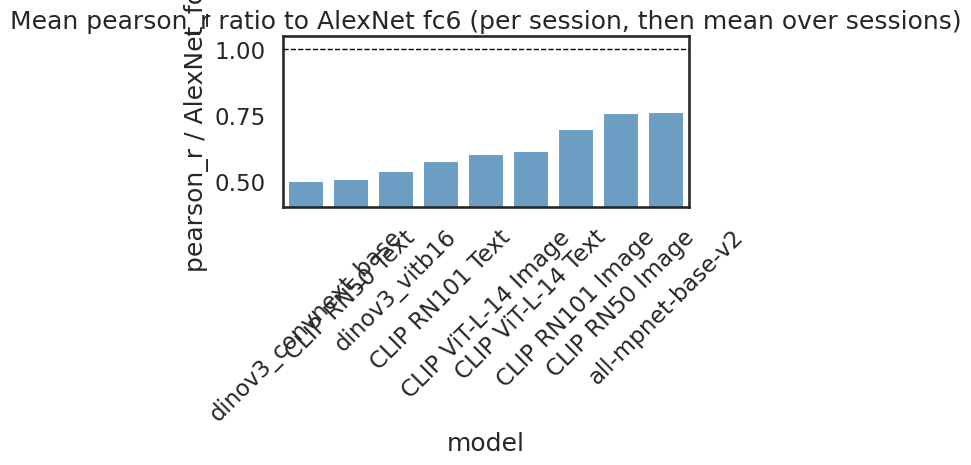

已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_session_bar.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/ratio_to_alexnet_by_session.csv


In [33]:
from matplotlib.backends.backend_pdf import PdfPages

out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
os.makedirs(out_dir, exist_ok=True)
alexnet_name = 'AlexNet fc6'

if rsa_all_subsample is not None:
    models_sub = sorted(rsa_all_subsample['model_name'].unique())
    pdf_sub = os.path.join(out_dir, 'pearson_r_all_subsample20pct_by_model.pdf')
    with PdfPages(pdf_sub) as pdf:
        for m in models_sub:
            sub = rsa_all_subsample.loc[
                rsa_all_subsample['model_name'] == m,
                ['repeat', 'pearson_r', 'n_units_sampled'],
            ].dropna()
            if len(sub) == 0:
                continue
            fig, ax = plt.subplots(figsize=(5, 4.5))
            xj = np.random.default_rng(0).normal(0, 0.06, size=len(sub))
            ax.scatter(xj, sub['pearson_r'].values, s=14, alpha=0.45, c='#5E9FD1', linewidths=0)
            mu = float(sub['pearson_r'].mean())
            ax.axhline(mu, color='#EC6F7E', linewidth=1.5)
            k = int(sub['n_units_sampled'].iloc[0])
            ax.set_xticks([])
            ax.set_xlim(-0.5, 0.5)
            ax.set_ylabel('pearson_r')
            ax.set_ylim(0, 0.35)
            ax.set_title(f'{m} | random 20% of units / repeat (k={k}, n_rep={len(sub)})')
            ax.grid(False)
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    print('已保存:', pdf_sub)

    rdf = rsa_all_subsample[['model_name', 'repeat', 'pearson_r']].dropna().copy()
    if alexnet_name in set(rdf['model_name'].unique()):
        alex_r = rdf.loc[rdf['model_name'] == alexnet_name, ['repeat', 'pearson_r']].rename(
            columns={'pearson_r': 'pearson_r_alexnet'}
        )
        oth = rdf.loc[rdf['model_name'] != alexnet_name].merge(alex_r, on='repeat', how='inner')
        oth = oth[oth['pearson_r_alexnet'] != 0].copy()
        oth['ratio_to_alexnet'] = oth['pearson_r'] / oth['pearson_r_alexnet']
        plot_sub = oth.groupby('model_name', as_index=False)['ratio_to_alexnet'].mean()
        pdf_ratio_sub = os.path.join(out_dir, 'ratio_to_alexnet_all_subsample20pct_bar.pdf')
        csv_ratio_sub = os.path.join(out_dir, 'ratio_to_alexnet_all_subsample20pct.csv')
        fig, ax = plt.subplots(figsize=(max(6, 0.35 * len(plot_sub)), 5))
        order_sub = plot_sub.sort_values('ratio_to_alexnet', ascending=True)['model_name'].tolist()
        sns.barplot(data=plot_sub, x='model_name', y='ratio_to_alexnet', order=order_sub, color='#5E9FD1', ax=ax)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title('Mean pearson_r ratio to AlexNet fc6 (all 20% subsample, across repeats)')
        ax.set_xlabel('model')
        ax.set_ylabel('pearson_r / AlexNet_fc6')
        ax.set_ylim(0.4, 1.05)
        ax.tick_params(axis='x', rotation=45)
        fig.tight_layout()
        fig.savefig(pdf_ratio_sub, dpi=300, bbox_inches='tight')
        plt.show()
        plot_sub.to_csv(csv_ratio_sub, index=False)
        print('已保存:', pdf_ratio_sub)
        print('已保存:', csv_ratio_sub)
    else:
        print('跳过 all_subsample ratio 图: 未找到', alexnet_name)

if rsa_by_session is not None:
    models_sess = sorted(rsa_by_session['model_name'].unique())
    pdf_sess = os.path.join(out_dir, 'pearson_r_by_session_per_model.pdf')
    with PdfPages(pdf_sess) as pdf:
        for m in models_sess:
            sub = rsa_by_session.loc[
                rsa_by_session['model_name'] == m,
                ['session_id', 'pearson_r', 'n_units'],
            ].dropna()
            if len(sub) == 0:
                continue
            order_sess = sorted(sub['session_id'].unique(), key=lambda x: str(x))
            n_sess = len(order_sess)
            w = min(36, max(10, 0.22 * n_sess))
            fig, ax = plt.subplots(figsize=(w, 4.5))
            sns.barplot(
                data=sub,
                x='session_id',
                y='pearson_r',
                order=order_sess,
                color='#5E9FD1',
                ax=ax,
            )
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
            ax.set_ylim(0, 0.35)
            ax.set_xlabel('session_id')
            ax.set_ylabel('pearson_r')
            ax.set_title(f'{m} | all units per session')
            ax.grid(False)
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    print('已保存:', pdf_sess)

    rdf_s = rsa_by_session[['model_name', 'session_id', 'pearson_r']].dropna().copy()
    if alexnet_name in set(rdf_s['model_name'].unique()):
        alex_s = rdf_s.loc[rdf_s['model_name'] == alexnet_name, ['session_id', 'pearson_r']].rename(
            columns={'pearson_r': 'pearson_r_alexnet'}
        )
        oth_s = rdf_s.loc[rdf_s['model_name'] != alexnet_name].merge(alex_s, on='session_id', how='inner')
        oth_s = oth_s[oth_s['pearson_r_alexnet'] != 0].copy()
        oth_s['ratio_to_alexnet'] = oth_s['pearson_r'] / oth_s['pearson_r_alexnet']
        plot_sess = oth_s.groupby('model_name', as_index=False)['ratio_to_alexnet'].mean()
        pdf_ratio_sess = os.path.join(out_dir, 'ratio_to_alexnet_by_session_bar.pdf')
        csv_ratio_sess = os.path.join(out_dir, 'ratio_to_alexnet_by_session.csv')
        fig, ax = plt.subplots(figsize=(max(6, 0.35 * len(plot_sess)), 5))
        order_sess_m = plot_sess.sort_values('ratio_to_alexnet', ascending=True)['model_name'].tolist()
        sns.barplot(data=plot_sess, x='model_name', y='ratio_to_alexnet', order=order_sess_m, color='#5E9FD1', ax=ax)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title('Mean pearson_r ratio to AlexNet fc6 (per session, then mean over sessions)')
        ax.set_xlabel('model')
        ax.set_ylabel('pearson_r / AlexNet_fc6')
        ax.set_ylim(0.4, 1.05)
        ax.tick_params(axis='x', rotation=45)
        fig.tight_layout()
        fig.savefig(pdf_ratio_sess, dpi=300, bbox_inches='tight')
        plt.show()
        plot_sess.to_csv(csv_ratio_sess, index=False)
        print('已保存:', pdf_ratio_sess)
        print('已保存:', csv_ratio_sess)
    else:
        print('跳过 session ratio 图: 未找到', alexnet_name)


In [34]:
from matplotlib.backends.backend_pdf import PdfPages

if rsa_all_subsample is None:
    print('跳过: rsa_all_subsample 未加载')
else:
    out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
    os.makedirs(out_dir, exist_ok=True)
    pdf_path = os.path.join(out_dir, 'rsa_all_subsample20pct_scatter_vs_alexnet_pearson.pdf')
    csv_slope_path = os.path.join(out_dir, 'rsa_all_subsample20pct_scatter_vs_alexnet_slopes.csv')

    base_name = 'AlexNet fc6'
    rdf = rsa_all_subsample[['model_name', 'repeat', 'pearson_r']].dropna().copy()
    if base_name not in rdf['model_name'].unique():
        raise ValueError('未找到基准模型: ' + base_name)

    alex_df = rdf.loc[rdf['model_name'] == base_name, ['repeat', 'pearson_r']].rename(
        columns={'pearson_r': 'x'}
    )
    other_models = sorted([m for m in rdf['model_name'].unique() if m != base_name])

    slope_rows = []
    with PdfPages(pdf_path) as pdf:
        for m in other_models:
            ydf = rdf.loc[rdf['model_name'] == m, ['repeat', 'pearson_r']].rename(columns={'pearson_r': 'y'})
            df = ydf.merge(alex_df, on='repeat', how='inner')
            df = df[(df['x'] >= 0) & (df['x'] <= 1) & (df['y'] >= 0) & (df['y'] <= 1)].copy()
            x_data = df['x'].to_numpy(dtype=float)
            y_data = df['y'].to_numpy(dtype=float)
            if len(x_data) == 0:
                continue
            denom = np.sum(x_data ** 2)
            if denom <= 0:
                a = np.nan
            else:
                a = float(np.sum(x_data * y_data) / denom)

            x_lo, x_hi = 0.35, 0.45
            y_span = 0.1
            lo_d = float(np.min(y_data))
            hi_d = float(np.max(y_data))
            if hi_d - lo_d <= y_span - 1e-15:
                c = 0.5 * (lo_d + hi_d)
                y_lo = c - 0.5 * y_span
            else:
                y_lo = lo_d
                if y_lo + y_span < hi_d:
                    y_lo = hi_d - y_span
            y_hi = y_lo + y_span
            y_lo = max(0.0, y_lo)
            y_hi = y_lo + y_span
            if y_hi > 1.0:
                y_hi = 1.0
                y_lo = y_hi - y_span

            fig, ax = plt.subplots(figsize=(3, 3))
            ax.scatter(x_data, y_data, s=8, color='#5E9FD1', linewidths=0)
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_xlabel(base_name + ' (pearson_r)')
            ax.set_ylabel(m + ' (pearson_r)')
            ax.plot([x_lo, x_hi], [y_lo, y_hi], linestyle='--', color='black', linewidth=1)
            if np.isfinite(a):
                ax.plot([x_lo, x_hi], [a * x_lo, a * x_hi], color='#EC6F7E', linewidth=1.5)
                ax.text(0.05, 0.95, f'slope={a:.3f}', transform=ax.transAxes, ha='left', va='top', color='#EC6F7E')
            ax.set_aspect('equal', adjustable='box')
            fig.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

            slope_rows.append({'y_model': m, 'n_points': len(x_data), 'slope_origin': a})

    pd.DataFrame(slope_rows).to_csv(csv_slope_path, index=False)
    print('已保存:', pdf_path)
    print('已保存:', csv_slope_path)


已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample20pct_scatter_vs_alexnet_pearson.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample20pct_scatter_vs_alexnet_slopes.csv


mean pearson bar: n_models= 10
slope bar: n_models= 9 n_fold_rows= 90


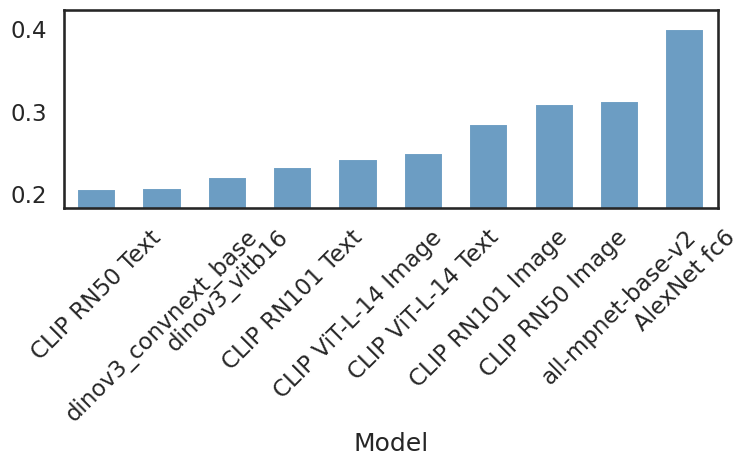

已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample_mean_pearson_r_bar_sorted.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample_mean_pearson_r_bar_sorted.csv


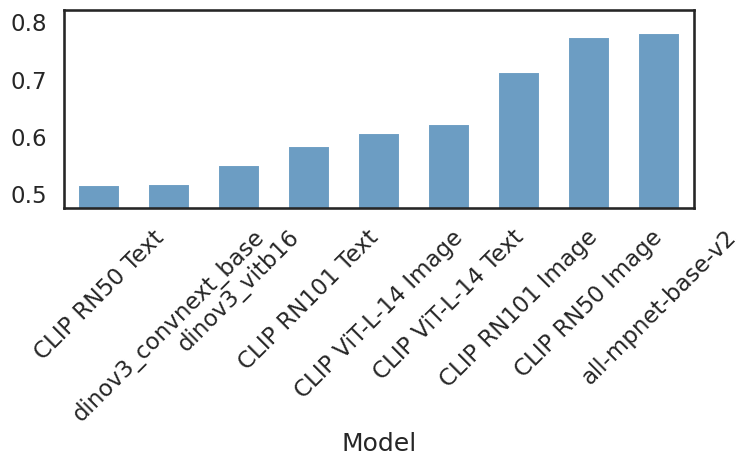

已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample_slope_vs_alexnet_bar_sorted.pdf
已保存: /media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures/rsa_all_subsample_slope_vs_alexnet_folds_long.csv


In [35]:
if rsa_all_subsample is None:
    print('跳过: rsa_all_subsample 未加载')
else:
    out_dir = '/media/ubuntu/sda/TrippleN/customize/RSA_analysis/figures'
    os.makedirs(out_dir, exist_ok=True)
    base_name = 'AlexNet fc6'

    rows_mean = []
    for m in sorted(rsa_all_subsample['model_name'].unique()):
        pr = rsa_all_subsample.loc[rsa_all_subsample['model_name'] == m, 'pearson_r'].dropna().to_numpy()
        valid = (pr >= 0) & (pr <= 1)
        pv = pr[valid]
        mean_val = float(np.mean(pv)) if len(pv) > 0 else np.nan
        rows_mean.append((m, mean_val))
    df_mean_plot = pd.DataFrame(rows_mean, columns=['model', 'mean_pearson_r'])
    order_mean = df_mean_plot.sort_values('mean_pearson_r')['model'].tolist()
    print('mean pearson bar: n_models=', len(order_mean))

    alex_df = rsa_all_subsample.loc[
        rsa_all_subsample['model_name'] == base_name,
        ['repeat', 'pearson_r'],
    ].rename(columns={'pearson_r': 'x'})
    other_models = sorted([m for m in rsa_all_subsample['model_name'].unique() if m != base_name])
    reps = np.sort(rsa_all_subsample['repeat'].unique().astype(np.int64))
    n_fold = 10
    folds = np.array_split(reps, n_fold)

    long_slope = []
    for m in other_models:
        ydf = rsa_all_subsample.loc[
            rsa_all_subsample['model_name'] == m,
            ['repeat', 'pearson_r'],
        ].rename(columns={'pearson_r': 'y'})
        merged = ydf.merge(alex_df, on='repeat', how='inner')
        merged = merged[(merged['x'] >= 0) & (merged['x'] <= 1) & (merged['y'] >= 0) & (merged['y'] <= 1)].copy()
        merged['repeat'] = merged['repeat'].astype(np.int64)
        for fi, rep_group in enumerate(folds):
            rg = np.asarray(rep_group, dtype=np.int64)
            sub = merged.loc[merged['repeat'].isin(rg)]
            x = sub['x'].to_numpy(dtype=float)
            y = sub['y'].to_numpy(dtype=float)
            denom = np.sum(x ** 2)
            if len(x) >= 2 and denom > 1e-15:
                a = float(np.sum(x * y) / denom)
            else:
                a = np.nan
            long_slope.append({'model': m, 'fold': fi, 'slope_fold': a})

    slope_long_df = pd.DataFrame(long_slope).dropna(subset=['slope_fold'])
    order_slope = slope_long_df.groupby('model')['slope_fold'].mean().sort_values(ascending=True).index.tolist()
    print('slope bar: n_models=', len(order_slope), 'n_fold_rows=', len(slope_long_df))

    bar_w = max(8, 0.35 * max(len(order_mean), len(order_slope)))
    bar_h = 5

    fig, ax = plt.subplots(figsize=(bar_w, bar_h))
    sns.barplot(data=df_mean_plot, x='model', y='mean_pearson_r', order=order_mean, ax=ax, color='#5E9FD1', width=0.6)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Model')
    ax.set_ylabel('')
    vm = df_mean_plot['mean_pearson_r'].dropna()
    if len(vm) > 0:
        lo, hi = float(vm.min()), float(vm.max())
        pad = max(0.02, (hi - lo) * 0.12)
        ax.set_ylim(max(0.0, lo - pad), min(1.0, hi + pad))
    fig.tight_layout()
    p_mean = os.path.join(out_dir, 'rsa_all_subsample_mean_pearson_r_bar_sorted.pdf')
    fig.savefig(p_mean, dpi=300, bbox_inches='tight')
    plt.show()
    csv_mean = os.path.join(out_dir, 'rsa_all_subsample_mean_pearson_r_bar_sorted.csv')
    df_mean_plot.to_csv(csv_mean, index=False)
    print('已保存:', p_mean)
    print('已保存:', csv_mean)

    plot_slope = slope_long_df.groupby('model', as_index=False)['slope_fold'].mean()
    fig2, ax2 = plt.subplots(figsize=(bar_w, bar_h))
    sns.barplot(
        data=plot_slope,
        x='model',
        y='slope_fold',
        order=order_slope,
        ax=ax2,
        color='#5E9FD1',
        errorbar=None,
        width=0.6,
    )
    ys = plot_slope['slope_fold'].to_numpy(dtype=float)
    lo, hi = float(np.min(ys)), float(np.max(ys))
    pad = max(0.02, (hi - lo) * 0.15)
    ax2.set_ylim(max(0.0, lo - pad), hi + pad)
    ax2.set_ylabel('')
    ax2.set_xlabel('Model')
    ax2.tick_params(axis='x', rotation=45)
    fig2.tight_layout()
    p_slope = os.path.join(out_dir, 'rsa_all_subsample_slope_vs_alexnet_bar_sorted.pdf')
    fig2.savefig(p_slope, dpi=300, bbox_inches='tight')
    plt.show()
    csv_slope_long = os.path.join(out_dir, 'rsa_all_subsample_slope_vs_alexnet_folds_long.csv')
    slope_long_df.to_csv(csv_slope_long, index=False)
    print('已保存:', p_slope)
    print('已保存:', csv_slope_long)
